In [1]:
from scipy.signal import stft
import scipy.stats

rzeczy do dodania:
- stft
- sk (spectral kurtosis)
- Jarque-Bera statistic
- KSS (Kolmogorov-Smirnov statistic)
- Anderson-Darling statistic
- QQplot (visual)
- local maxima selector

# dane testowe


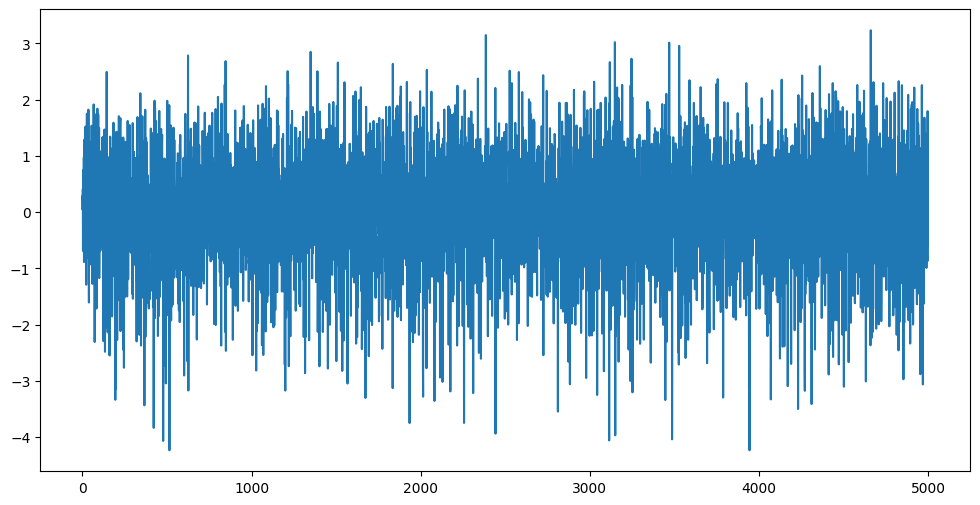

In [2]:
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt

#częstotliwość próbkowania 1000Hz

data = loadmat('assets/vibration_dataset/versions/1/Healthy/H1.mat')
# sygnał jest wyrażony w trzech płaszczyznach X, Y, Z
signal = data['H'][:,1]
plt.figure(figsize = (12 , 6))
plt.plot(signal)


# Short term Fourier Transform

In [5]:
array_freq, array_tt, matrix_Zxx =stft(signal, fs = 1000, window = 'hann')
abs_Zxx = np.abs(matrix_Zxx)
# print(array_freq)
# print(array_tt)
# i = 5
# print(np.abs(matrix_Zxx[i]))
# plt.plot(np.abs(matrix_Zxx[i]))


# Spectral Kurtosis (SK)

In [13]:
def SK(Zxx,f,t):
    abs_Zxx = np.abs(Zxx)
    num = np.sum(np.pow(abs_Zxx[f,:],4))
    denum = np.sum(np.pow(abs_Zxx[f,:],2))
    T = len(t)
    return (T*num/denum)-2 

Calculating SK for frequenzy 0.0:
-1.6193163784780857
Calculating SK for frequenzy 3.90625:
-1.776496102977622
Calculating SK for frequenzy 7.8125:
-1.843007466832638
Calculating SK for frequenzy 11.71875:
-1.7872319730178552
Calculating SK for frequenzy 15.625:
-1.7304500686703181
Calculating SK for frequenzy 19.53125:
-1.8189438700814269
Calculating SK for frequenzy 23.4375:
-1.8245724220132031
Calculating SK for frequenzy 27.34375:
-1.7553233381994446
Calculating SK for frequenzy 31.25:
-1.627076887371511
Calculating SK for frequenzy 35.15625:
-1.4159569485727217
Calculating SK for frequenzy 39.0625:
-1.4523893254879199
Calculating SK for frequenzy 42.96875:
-1.474565328177131
Calculating SK for frequenzy 46.875:
-1.4681848941181528
Calculating SK for frequenzy 50.78125:
-1.1188329107523916
Calculating SK for frequenzy 54.6875:
-1.6667217849243006
Calculating SK for frequenzy 58.59375:
-1.7384760479458454
Calculating SK for frequenzy 62.5:
-1.5972492423554454
Calculating SK for freq

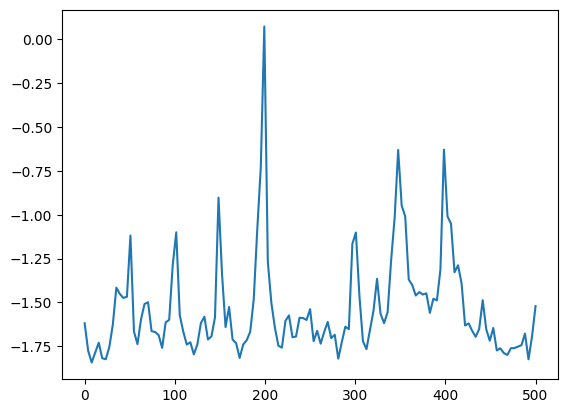

In [19]:
result = np.zeros_like(array_freq)

for i in range(0,len(array_freq)):
    print(f"Calculating SK for frequenzy {array_freq[i]}:")
    result[i] = SK(matrix_Zxx,i,array_tt)
    print(SK(matrix_Zxx,i,array_tt))

plt.plot(array_freq,result)

STFT analizuje, jak moc sygnału w danym paśmie zmienia się w czasie.

Jeśli ta moc zmienia się losowo, ale z rozkładem normalnym → SK ≈ 0.

Jeśli pojawiają się momenty, gdzie moc „wystrzela” (impulsowe zdarzenia) → SK > 0.

Jeśli sygnał jest bardzo „gładki” → SK < 0.

# Jarque–Bera test (JB)


In [ ]:
def JB(Zxx, f, t):
    abs_Zxx = np.abs(Zxx)
    s = scipy.stats.skew(abs_Zxx[f])
    k = scipy.stats.kurtosis(abs_Zxx[f])
    T = len(t)
    print(f"Skewness: {s}, kurtosis: {k}")
    return T/6 * (s**2 + (np.power(k-1,2)/4))

for i in range(0,len(array_freq)):
    print(f"Calculating JB for frequenzy {array_freq[i]}:")
    print(f"JB statistic: {JB(matrix_Zxx,i,array_tt)}")

Calculating JB for frequenzy 0.0:
Skewness: 1.1315311262893635, kurtosis: 1.1279899670270916
JB statistic: 8.77712999245659
Calculating JB for frequenzy 3.90625:
Skewness: 0.5582628879962381, kurtosis: 0.659348524677712
JB statistic: 2.32790011166204
Calculating JB for frequenzy 7.8125:
Skewness: 0.3154618552308381, kurtosis: -0.6453497066607699
JB statistic: 5.304785658786993
Calculating JB for frequenzy 11.71875:
Skewness: 1.0995626758923651, kurtosis: 2.0890826829076303
JB statistic: 10.288016230247308
Calculating JB for frequenzy 15.625:
Skewness: 1.8848292330583982, kurtosis: 6.957365681676103
JB statistic: 84.90507347797946
Calculating JB for frequenzy 19.53125:
Skewness: 0.492854325016838, kurtosis: -0.07741185253698557
JB statistic: 3.6429146480114185
Calculating JB for frequenzy 23.4375:
Skewness: 0.8769129444012139, kurtosis: 1.464673098712196
JB statistic: 5.623536658871552
Calculating JB for frequenzy 27.34375:
Skewness: 0.526633554273094, kurtosis: -0.330239950278135
JB st

# Kolmogorov-Smirnov Statistic (KSS)

In [ ]:
def KSS(Zxx,f,t):
    abs_Zxx = np.abs(Zxx)
    mean_signal = np.mean(abs_Zxx[f])
    std_signal = np.std(abs_Zxx[f])
    cdf_sample = np.zeros_like(t)
    for i in range(len(t)):
        cdf_sample[i] = scipy.stats.norm.cdf(t[i],loc=mean_signal, scale=std_signal)
    return(scipy.stats.kstest(abs_Zxx[f],cdf_sample))



In [ ]:
for i in range(0,len(array_freq)):
    print(f"Calculating KSS for frequenzy {array_freq[i]}:")
    p_value = KSS(matrix_Zxx,i,array_tt).pvalue
    print(f"KSS statistic: {p_value}")

Calculating KSS for frequenzy 0.0:
KSS statistic: 3.860780437752712e-22
Calculating KSS for frequenzy 3.90625:
KSS statistic: 3.860780437752712e-22
Calculating KSS for frequenzy 7.8125:
KSS statistic: 3.860780437752712e-22
Calculating KSS for frequenzy 11.71875:
KSS statistic: 3.860780437752712e-22
Calculating KSS for frequenzy 15.625:
KSS statistic: 3.860780437752712e-22
Calculating KSS for frequenzy 19.53125:
KSS statistic: 3.860780437752712e-22
Calculating KSS for frequenzy 23.4375:
KSS statistic: 3.860780437752712e-22
Calculating KSS for frequenzy 27.34375:
KSS statistic: 3.860780437752712e-22
Calculating KSS for frequenzy 31.25:
KSS statistic: 3.860780437752712e-22
Calculating KSS for frequenzy 35.15625:
KSS statistic: 3.860780437752712e-22
Calculating KSS for frequenzy 39.0625:
KSS statistic: 3.860780437752712e-22
Calculating KSS for frequenzy 42.96875:
KSS statistic: 3.860780437752712e-22
Calculating KSS for frequenzy 46.875:
KSS statistic: 3.860780437752712e-22
Calculating KSS 

## Narysowanie dustrybuant (wymaga dużo poprawek)

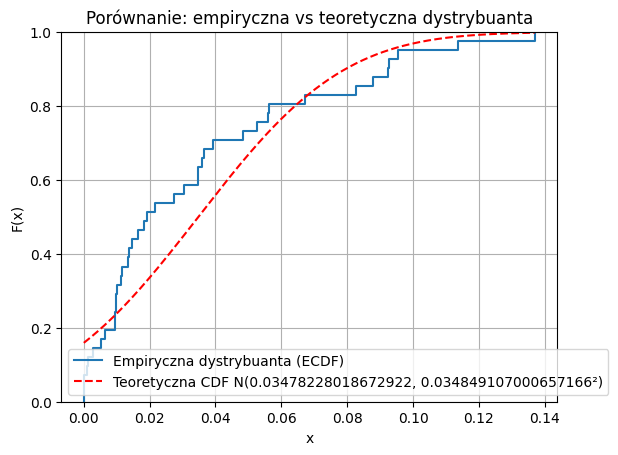

In [ ]:
from scipy.stats import norm
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

mean_signal = np.mean(abs_Zxx[0])
std_signal = np.std(abs_Zxx[0])
cdf_sample = np.zeros_like(array_tt)
for i in range(len(array_tt)):
    cdf_sample[i] = scipy.stats.norm.cdf(array_tt[i],loc=mean_signal, scale=std_signal)


# Obliczamy ECDF
n = len(abs_Zxx[0])
ecdf = np.arange(1, n + 1) / n




# Oś X dla CDF teoretycznej
x = np.linspace(np.min(abs_Zxx[0]), np.max(abs_Zxx[0]), 200)
cdf_theoretical = norm.cdf(x, loc=mean_signal, scale=std_signal)

# Rysunek
sns.ecdfplot(data=abs_Zxx[0], label="Empiryczna dystrybuanta (ECDF)")
plt.plot(x, cdf_theoretical, 'r--', label=f"Teoretyczna CDF N({mean_signal}, {std_signal}²)")
plt.title("Porównanie: empiryczna vs teoretyczna dystrybuanta")
plt.xlabel("x")
plt.ylabel("F(x)")
plt.legend()
plt.grid(True)
plt.show()

# Anderson Darling statistic(Q)

Tutaj będzie trzeba się trochę bardziej zagłębić w to, co jest zwracane w tej funkcji, bo nie ma bezpośrednio zwróconej p-wartości, tylko raczej wartości krytyczne(jeśli to nie jest to samo lol)

In [ ]:
for i in range(0,len(array_freq)):
    print(f"Calculating Q for frequenzy {array_freq[i]}:")
    stat,crit,signi = scipy.stats.anderson(abs_Zxx[i]).statistic,scipy.stats.anderson(abs_Zxx[i]).critical_values,scipy.stats.anderson(abs_Zxx[i]).significance_level
    print(f"Q statistic: {np.abs(stat)}")
    print(crit)
    print(signi)

Calculating Q for frequenzy 0.0:
Q statistic: 2.2454327849103635
[0.532 0.606 0.727 0.848 1.009]
[15.  10.   5.   2.5  1. ]
Calculating Q for frequenzy 3.90625:
Q statistic: 0.75936578295061
[0.532 0.606 0.727 0.848 1.009]
[15.  10.   5.   2.5  1. ]
Calculating Q for frequenzy 7.8125:
Q statistic: 1.044146122901033
[0.532 0.606 0.727 0.848 1.009]
[15.  10.   5.   2.5  1. ]
Calculating Q for frequenzy 11.71875:
Q statistic: 0.6274090695283903
[0.532 0.606 0.727 0.848 1.009]
[15.  10.   5.   2.5  1. ]
Calculating Q for frequenzy 15.625:
Q statistic: 1.063847552892085
[0.532 0.606 0.727 0.848 1.009]
[15.  10.   5.   2.5  1. ]
Calculating Q for frequenzy 19.53125:
Q statistic: 0.8813342661776602
[0.532 0.606 0.727 0.848 1.009]
[15.  10.   5.   2.5  1. ]
Calculating Q for frequenzy 23.4375:
Q statistic: 0.7861212736207221
[0.532 0.606 0.727 0.848 1.009]
[15.  10.   5.   2.5  1. ]
Calculating Q for frequenzy 27.34375:
Q statistic: 0.649973428757221
[0.532 0.606 0.727 0.848 1.009]
[15.  10.  

# QQplot

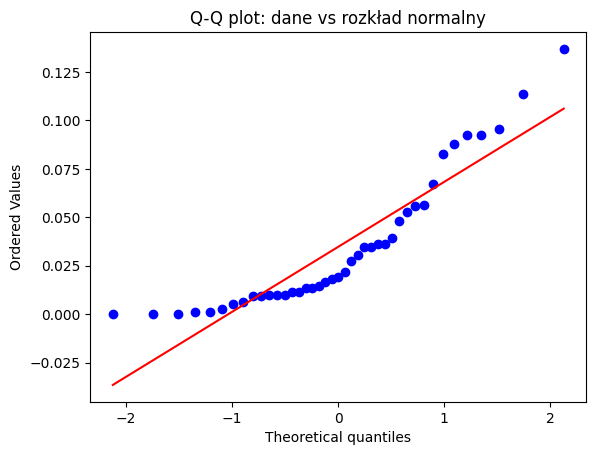

In [ ]:
temp = abs_Zxx[0]
scipy.stats.probplot(temp, dist="norm", plot=plt)
plt.title("Q-Q plot: dane vs rozkład normalny")
plt.show()

# Local maxima


In [ ]:
def M(matrix,t,f):
    maxima_row = (matrix[:,t] == np.max(matrix[:,t])).astype(int)
    print(maxima_row)
    print(f)
    return maxima_row[f]
    
def W(matrix_maxima,t,f):
    F = len(f)
    sum_result = 0
    for f_index in range(len(f)):
        sum_result += M(matrix_maxima,t,f_index)
    return 1/len(array_freq) * np.sum(matrix_maxima[:,t])

def ENH(matrix_maxima,t,f):
    return W(matrix_maxima,t,f)*M(matrix_maxima,t,f)

def LM(matrix_maxima,t,f):
    T = len(t)
    sum_result = 0
    for i in range(T):
        sum_result += ENH(matrix_maxima,i,f)
    return 1/T * sum_result

In [ ]:
for i in range(0,len(array_freq)):
    print(f"Calculating LM for frequenzy {array_freq[i]}:")
    print(LM(abs_Zxx,array_tt,arra))

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
0
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
1
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
2
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 

IndexError: arrays used as indices must be of integer (or boolean) type